In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error,mean_absolute_error


In [88]:
data_path="data\\ai data new.csv"


In [89]:
df=pd.read_csv(data_path)
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27 00:00:00.000,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
1,2023-01-03 00:00:00.000,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2,2023-01-10 00:00:00.000,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
3,2023-01-17 00:00:00.000,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
4,2023-01-24 00:00:00.000,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20 00:00:00.000,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56
516,2025-05-27 00:00:00.000,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00
517,2025-06-03 00:00:00.000,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31
518,2025-06-10 00:00:00.000,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95


In [90]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27 00:00:00.000,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
1,2023-01-03 00:00:00.000,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2,2023-01-10 00:00:00.000,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
3,2023-01-17 00:00:00.000,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
4,2023-01-24 00:00:00.000,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20 00:00:00.000,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56
516,2025-05-27 00:00:00.000,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00
517,2025-06-03 00:00:00.000,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31
518,2025-06-10 00:00:00.000,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95


In [91]:
column=["TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","NEXT_WEEK_TOTAL_AMOUNT"]

In [92]:
# for col in column:
#     df[col] = df[col].astype(float).astype(int)

In [93]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27 00:00:00.000,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
1,2023-01-03 00:00:00.000,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2,2023-01-10 00:00:00.000,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
3,2023-01-17 00:00:00.000,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
4,2023-01-24 00:00:00.000,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20 00:00:00.000,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56
516,2025-05-27 00:00:00.000,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00
517,2025-06-03 00:00:00.000,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31
518,2025-06-10 00:00:00.000,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95


In [94]:
df['RATIO_TOTAL_LAST_WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_WEEK_TOTAL_AMOUNT']
df['RATIO_TOTAL_LAST_2WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_2WEEK_TOTAL_AMOUNT']
df['RATIO_TRANS_LAST_WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_WEEK_TRANSACTION_COUNT']
df['RATIO_TRANS_LAST_2WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_2WEEK_TRANSACTION_COUNT']

In [95]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
0,2022-12-27 00:00:00.000,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37,NaN,NaN,NaN,NaN
1,2023-01-03 00:00:00.000,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,9.055818,NaN,8.582596,NaN
2,2023-01-10 00:00:00.000,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,1.081702,9.795700,1.071520,9.196419
3,2023-01-17 00:00:00.000,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,1.001595,1.083427,1.015750,1.088395
4,2023-01-24 00:00:00.000,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,2025-05-20 00:00:00.000,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,1.038131,1.029371,1.111540,1.063670
516,2025-05-27 00:00:00.000,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,1.084493,1.125845,1.014233,1.127360
517,2025-06-03 00:00:00.000,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31,0.992654,1.076525,0.965315,0.979054
518,2025-06-10 00:00:00.000,16,2025,6,24,15587878.31,100822,17400796.00,113021.0,17529576.56,117082.0,2718883.95,0.895814,0.889233,0.892064,0.861123


In [96]:
df.set_index('WEEK_START', inplace=True)

In [97]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-27 00:00:00.000,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37,NaN,NaN,NaN,NaN
2023-01-03 00:00:00.000,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,9.055818,NaN,8.582596,NaN
2023-01-10 00:00:00.000,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,1.081702,9.795700,1.071520,9.196419
2023-01-17 00:00:00.000,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,1.001595,1.083427,1.015750,1.088395
2023-01-24 00:00:00.000,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-20 00:00:00.000,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,1.038131,1.029371,1.111540,1.063670
2025-05-27 00:00:00.000,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,17400796.00,1.084493,1.125845,1.014233,1.127360
2025-06-03 00:00:00.000,16,2025,6,23,17400796.00,113021,17529576.56,117082.0,16163852.23,115439.0,15587878.31,0.992654,1.076525,0.965315,0.979054


In [98]:
split_date='2025-06-10'
df = df[df.index < split_date]

In [99]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-27 00:00:00.000,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37,NaN,NaN,NaN,NaN
2023-01-03 00:00:00.000,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53,9.055818,NaN,8.582596,NaN
2023-01-10 00:00:00.000,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80,1.081702,9.795700,1.071520,9.196419
2023-01-17 00:00:00.000,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15,1.001595,1.083427,1.015750,1.088395
2023-01-24 00:00:00.000,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06 00:00:00.000,16,2025,5,19,15702655.05,108529,19611872.05,127050.0,17876336.61,117691.0,15570153.12,0.800671,0.878405,0.854223,0.922152
2025-05-13 00:00:00.000,16,2025,5,20,15570153.12,103855,15702655.05,108529.0,19611872.05,127050.0,16163852.23,0.991562,0.793915,0.956933,0.817434
2025-05-20 00:00:00.000,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56,1.038131,1.029371,1.111540,1.063670


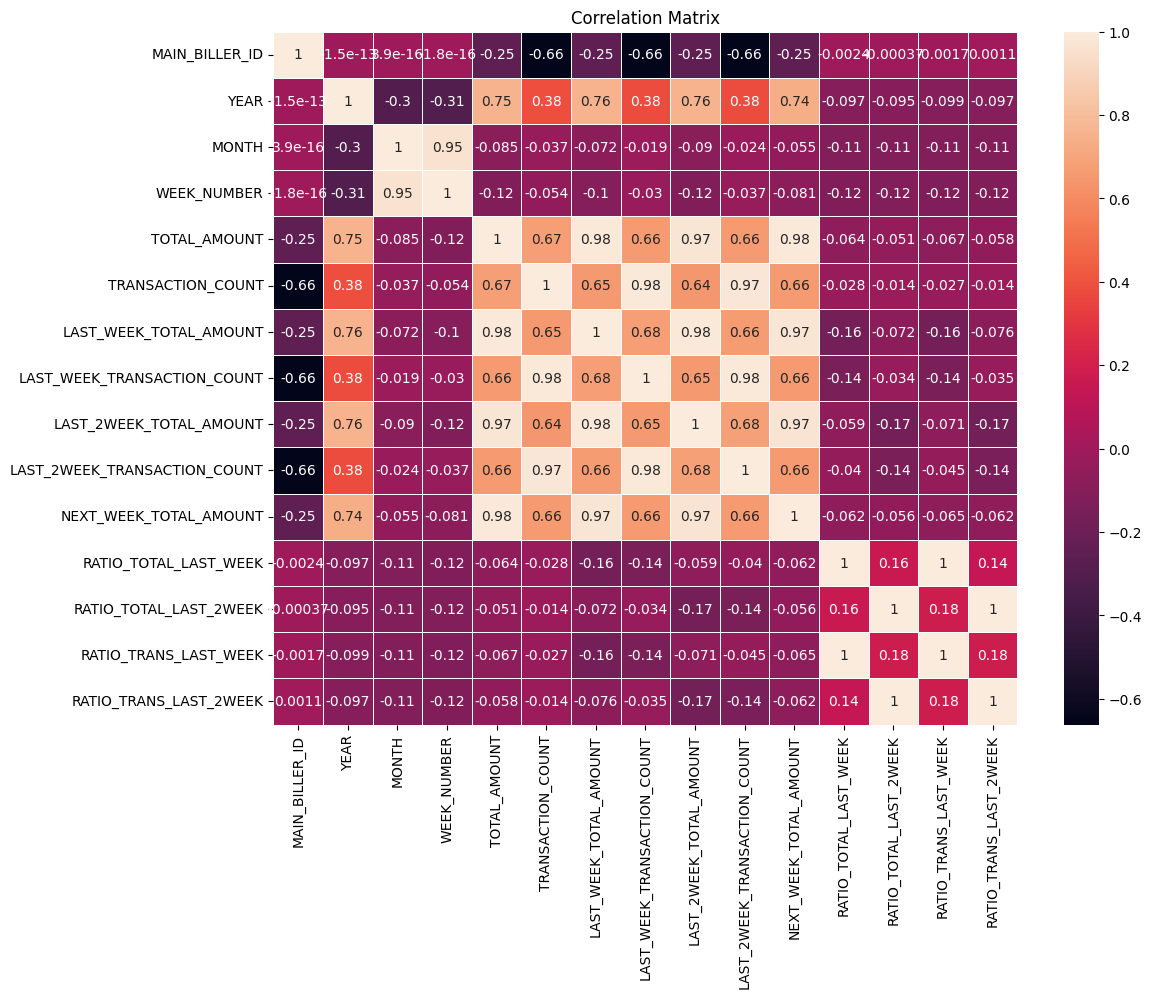

In [100]:
corr_matrix = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, ax=ax)
plt.title("Correlation Matrix")
plt.show()



In [101]:
correlation_matrix = df.corr()
corr_target = correlation_matrix['NEXT_WEEK_TOTAL_AMOUNT'].sort_values(ascending=False)
cols_to_drop = corr_target[corr_target < 0.1].index.tolist()
cols_to_keep = ['MAIN_BILLER_ID']
df = df[cols_to_keep + [col for col in df.columns.tolist() if col not in cols_to_drop]]

df

,MAIN_BILLER_ID,YEAR,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,,,,,,,,
2022-12-27 00:00:00.000,13,2022,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
2023-01-03 00:00:00.000,13,2023,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2023-01-10 00:00:00.000,13,2023,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
2023-01-17 00:00:00.000,13,2023,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
2023-01-24 00:00:00.000,13,2023,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...
2025-05-06 00:00:00.000,16,2025,15702655.05,108529,19611872.05,127050.0,17876336.61,117691.0,15570153.12
2025-05-13 00:00:00.000,16,2025,15570153.12,103855,15702655.05,108529.0,19611872.05,127050.0,16163852.23
2025-05-20 00:00:00.000,16,2025,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56


In [102]:
split_date='2025-05-13'
train_df = df[df.index < split_date]
test_df = df[df.index >= split_date]

In [103]:
train_df

,MAIN_BILLER_ID,YEAR,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,,,,,,,,
2022-12-27 00:00:00.000,13,2022,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
2023-01-03 00:00:00.000,13,2023,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2023-01-10 00:00:00.000,13,2023,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
2023-01-17 00:00:00.000,13,2023,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
2023-01-24 00:00:00.000,13,2023,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...
2025-04-08 00:00:00.000,16,2025,15630703.88,107803,17714663.86,121051.0,19608880.54,117056.0,15825971.44
2025-04-15 00:00:00.000,16,2025,15825971.44,113418,15630703.88,107803.0,17714663.86,121051.0,17876336.61
2025-04-22 00:00:00.000,16,2025,17876336.61,117691,15825971.44,113418.0,15630703.88,107803.0,19611872.05


In [104]:
test_df

,MAIN_BILLER_ID,YEAR,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,,,,,,,,
2025-05-13 00:00:00.000,13,2025,23903262.52,736450,24106173.86,742925.0,26168053.25,773146.0,24094654.79
2025-05-20 00:00:00.000,13,2025,24094654.79,737747,23903262.52,736450.0,24106173.86,742925.0,25321501.75
2025-05-27 00:00:00.000,13,2025,25321501.75,750389,24094654.79,737747.0,23903262.52,736450.0,25210754.96
2025-06-03 00:00:00.000,13,2025,25210754.96,767465,25321501.75,750389.0,24094654.79,737747.0,23428591.47
2025-05-13 00:00:00.000,14,2025,10907553.02,407647,11580632.17,424643.0,11948048.26,436537.0,11332411.62
2025-05-20 00:00:00.000,14,2025,11332411.62,414264,10907553.02,407647.0,11580632.17,424643.0,11995214.35
2025-05-27 00:00:00.000,14,2025,11995214.35,432853,11332411.62,414264.0,10907553.02,407647.0,11818208.92
2025-06-03 00:00:00.000,14,2025,11818208.92,438261,11995214.35,432853.0,11332411.62,414264.0,11195902.66
2025-05-13 00:00:00.000,15,2025,19656769.14,763044,20628451.31,781516.0,20664149.84,782460.0,20033865.91


In [105]:
# features=["MAIN_BILLER_ID","YEAR","MONTH","WEEK_NUMBER","TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","RATIO_TOTAL_LAST_WEEK","RATIO_TOTAL_LAST_2WEEK","RATIO_TRANS_LAST_WEEK","RATIO_TRANS_LAST_2WEEK"]
pred="NEXT_WEEK_TOTAL_AMOUNT"

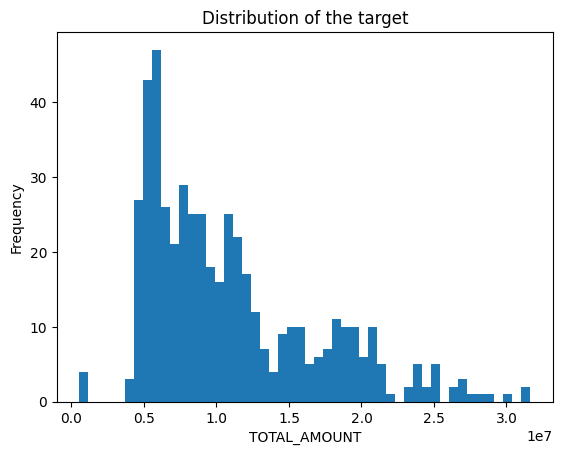

In [106]:

# distribution of the target
plt.hist(train_df['TOTAL_AMOUNT'], bins=50)
plt.title('Distribution of the target')
plt.xlabel('TOTAL_AMOUNT')
plt.ylabel('Frequency')
plt.show()


In [107]:
X_train = train_df.drop(pred, axis=1)   # features
y_train = train_df[pred]    # target

X_test = test_df.drop(pred, axis=1)
y_test = test_df[pred]    

In [108]:
features = list(X_test.columns)

In [109]:
X_train


,MAIN_BILLER_ID,YEAR,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT
WEEK_START,,,,,,,,
2022-12-27 00:00:00.000,13,2022,948753.84,59307,NaN,NaN,NaN,NaN
2023-01-03 00:00:00.000,13,2023,8591742.37,509008,948753.84,59307.0,NaN,NaN
2023-01-10 00:00:00.000,13,2023,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0
2023-01-17 00:00:00.000,13,2023,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0
2023-01-24 00:00:00.000,13,2023,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0
...,...,...,...,...,...,...,...,...
2025-04-08 00:00:00.000,16,2025,15630703.88,107803,17714663.86,121051.0,19608880.54,117056.0
2025-04-15 00:00:00.000,16,2025,15825971.44,113418,15630703.88,107803.0,17714663.86,121051.0
2025-04-22 00:00:00.000,16,2025,17876336.61,117691,15825971.44,113418.0,15630703.88,107803.0


## model

In [110]:
model =XGBRegressor(
    objective='reg:absoluteerror',  # regression objective
    n_estimators=3000,              # number of trees
    learning_rate=0.1,             # step size shrinkage
    max_depth=8,                   # maximum tree depth
    subsample=0.8,                 # % of data used per tree
    colsample_bytree=0.8,          # % of features used per tree
    reg_alpha=0.1,                 # L1 regularization term
    reg_lambda=1,                  # L2 regularization term
    random_state=42                # for reproducibility
)

# Fit the model
model.fit(X_train, y_train)

,objective,'reg:absoluteerror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


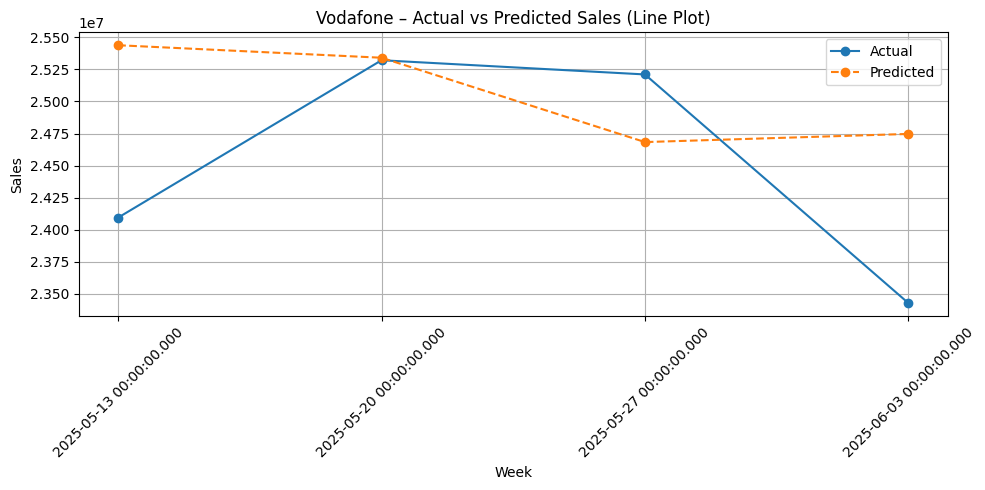

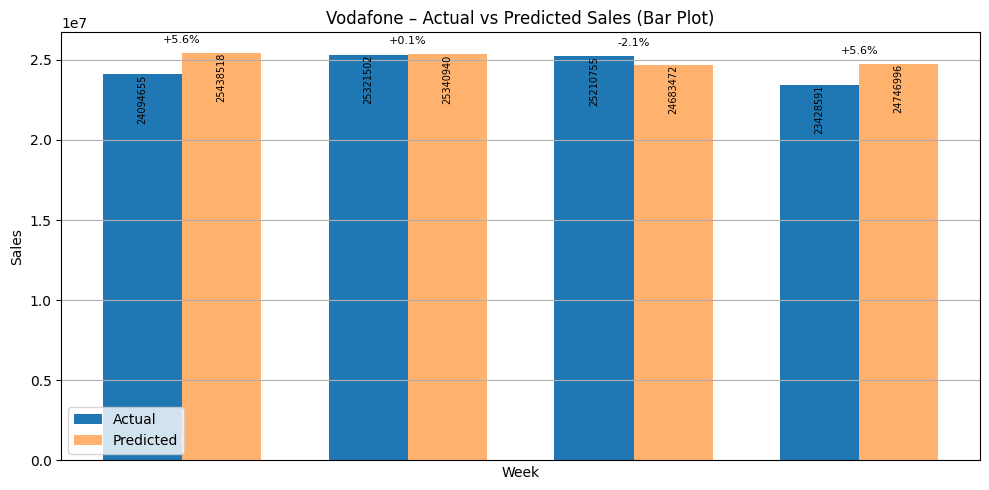

[Vodafone] MAE: 802247.24  (n=4)


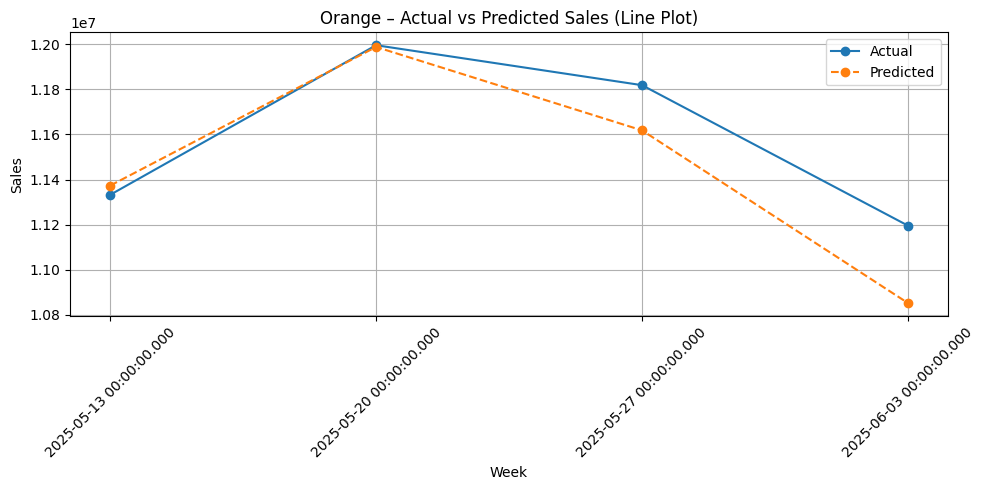

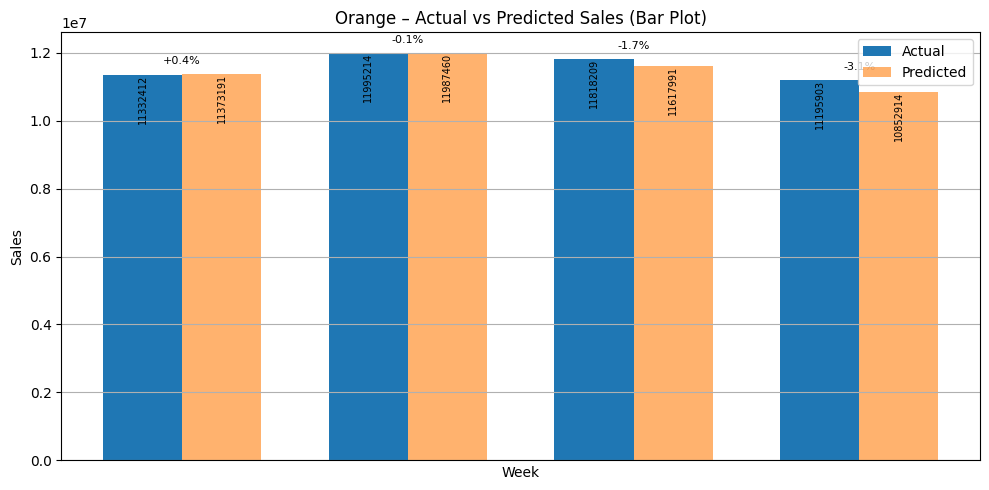

[Orange] MAE: 147935.08  (n=4)


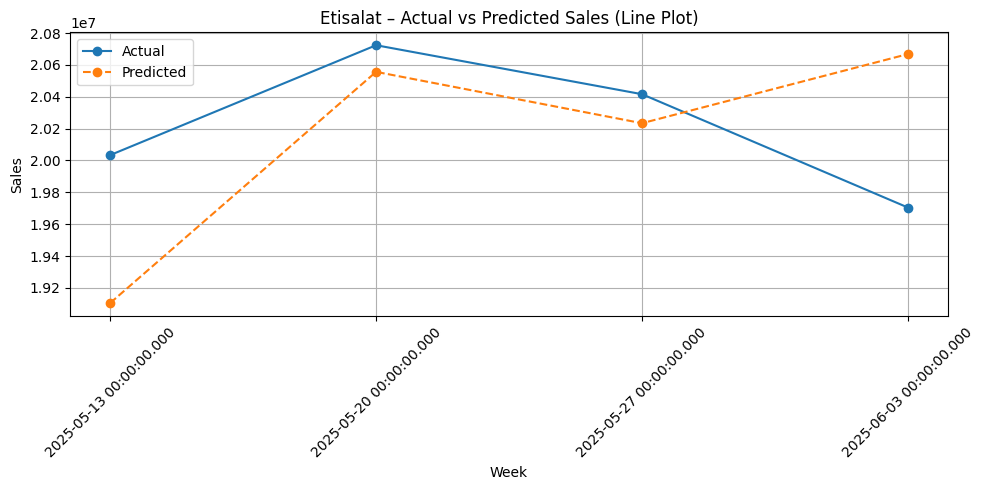

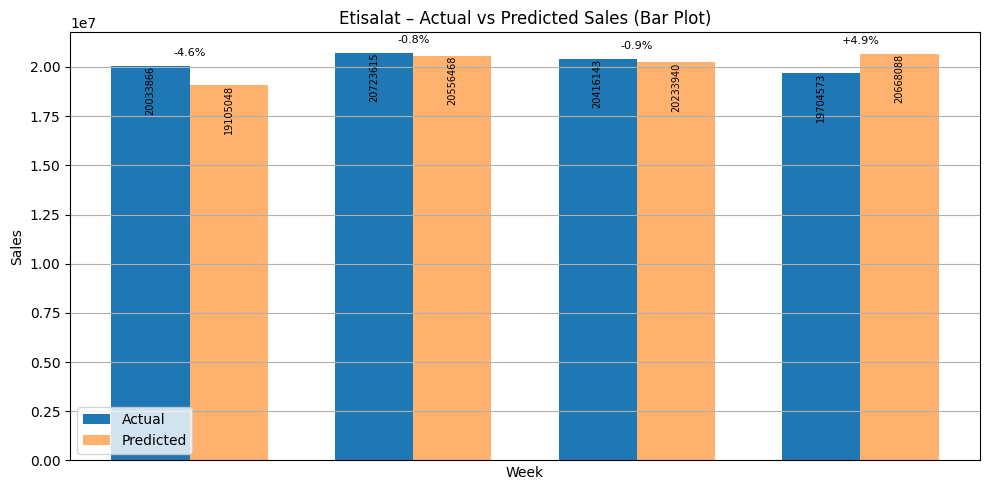

[Etisalat] MAE: 560420.54  (n=4)


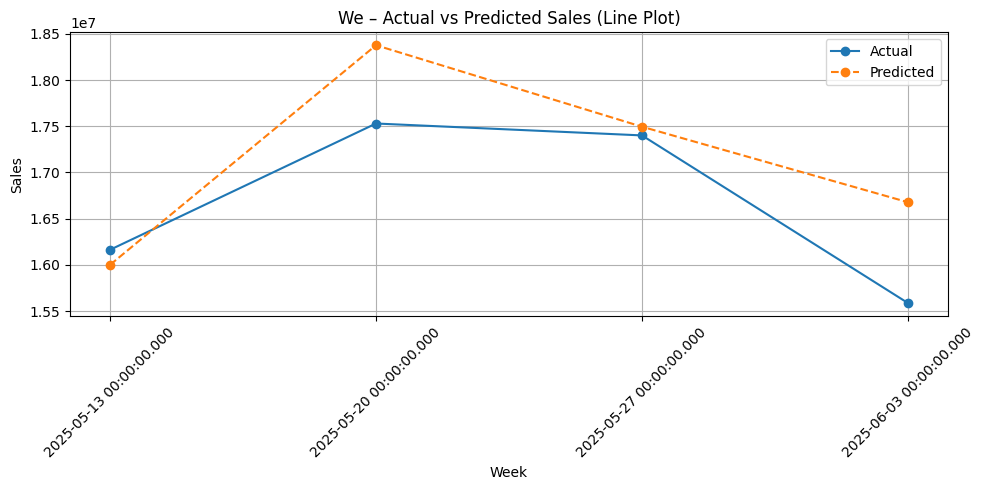

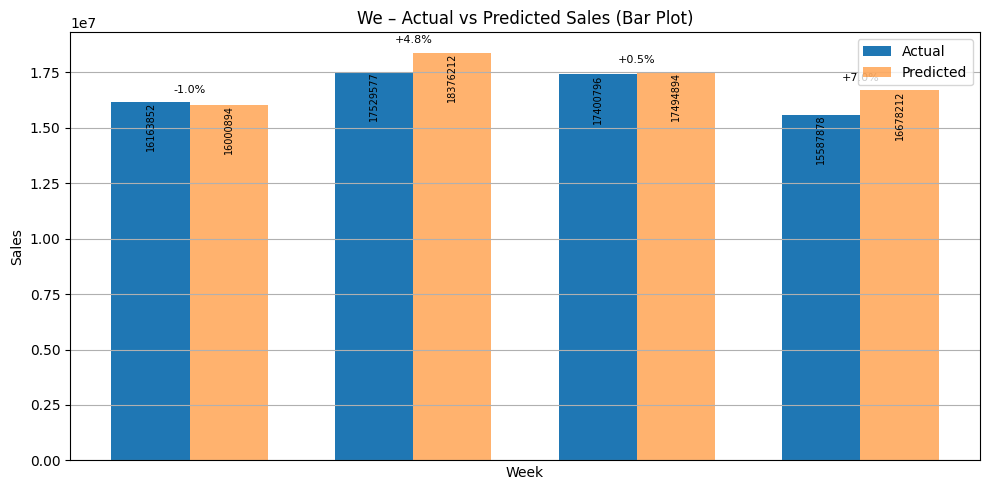

[We] MAE: 548506.34  (n=4)


In [111]:
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

all_actuals, all_preds = [], []

product_name = {13: 'Vodafone', 14: 'Orange', 15: 'Etisalat', 16: 'We'}

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    group = group.sort_index()

    X_test = group[features]
    y_true = group[pred].values.flatten()
    y_pred = model.predict(X_test).flatten()

    all_actuals.extend(y_true)
    all_preds.extend(y_pred)

    # ──────────────────────────── 1) LINE / DOT PLOT ────────────────────────────
    plt.figure(figsize=(10, 5))
    plt.plot(group.index, y_true, marker='o', label='Actual')
    plt.plot(group.index, y_pred, linestyle='--', marker='o', label='Predicted')
    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Line Plot)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ──────────────────────────── 2) BAR PLOT ────────────────────────────
    plt.figure(figsize=(10, 5))
    width = 0.35
    x = np.arange(len(y_true))

    plt.bar(x - width/2, y_true, width, label='Actual')
    plt.bar(x + width/2, y_pred, width, label='Predicted', alpha=0.6)

    # % deviation: positive → over-prediction, negative → under-prediction
    percent = (y_pred - y_true) / y_true * 100

    for i in range(len(x)):
        # actual & predicted numbers
        plt.text(i - width/2, y_true[i] - 3,  f"{y_true[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')
        plt.text(i + width/2, y_pred[i] - 3,  f"{y_pred[i]:.0f}",
                 ha='center', va='top', rotation=90, fontsize=7, color='black')

        # % deviation label
        tallest = max(y_true[i], y_pred[i])
        plt.text(i, tallest * 1.02, f"{percent[i]:+.1f}%",
                 ha='center', va='bottom', fontsize=8, color='black')

    plt.title(f"{product_name[product]} – Actual vs Predicted Sales (Bar Plot)")
    plt.xlabel("Week")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks([])          # hide week labels if desired
    plt.tight_layout()
    plt.show()

    # ──────────────────────────── 3) ERROR METRIC ────────────────────────────
    mae = mean_absolute_error(y_true, y_pred)
    print(f"[{product_name[product]}] MAE: {mae:.2f}  (n={len(y_true)})")

In [112]:
y_pred

array([1.6000894e+07, 1.8376212e+07, 1.7494894e+07, 1.6678212e+07],
      dtype=float32)

In [113]:
all_actuals

[np.float64(24094654.79),
 np.float64(25321501.75),
 np.float64(25210754.96),
 np.float64(23428591.47),
 np.float64(11332411.62),
 np.float64(11995214.35),
 np.float64(11818208.92),
 np.float64(11195902.66),
 np.float64(20033865.91),
 np.float64(20723614.86),
 np.float64(20416142.72),
 np.float64(19704573.31),
 np.float64(16163852.23),
 np.float64(17529576.56),
 np.float64(17400796.0),
 np.float64(15587878.31)]